In [5]:
import pandas as pd
import numpy as np

# This allows you to see all columns if the dataset is wide
pd.set_option('display.max_columns', None)

In [6]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

# --- DATASET 1: CUSTOMERS ---
customers_data = {
    'customer_id': [f'c_{i}' for i in range(100)],
    'customer_unique_id': [f'user_{np.random.randint(1, 50)}' for i in range(100)],
    'customer_city': ['sao paulo', 'rio de janeiro', 'belo horizonte'] * 33 + ['sao paulo']
}
customers = pd.DataFrame(customers_data)

# --- DATASET 2: ORDERS ---
# Generates timestamps over the last 60 days
start_date = datetime(2026, 1, 1)
orders_data = {
    'order_id': [f'ord_{i}' for i in range(100)],
    'customer_id': [f'c_{i}' for i in range(100)],
    'order_purchase_timestamp': [
        (start_date + timedelta(days=np.random.randint(0, 60))).strftime('%Y-%m-%d %H:%M:%S')
        for i in range(100)
    ]
}
orders = pd.DataFrame(orders_data)

# --- DATASET 3: ORDER ITEMS ---
items_data = {
    'order_id': [f'ord_{i}' for i in range(100)],
    'price': np.random.uniform(20, 500, 100),
    'freight_value': np.random.uniform(5, 50, 100)
}
items = pd.DataFrame(items_data)

print("All 3 datasets created: 'customers', 'orders', and 'items'")

All 3 datasets created: 'customers', 'orders', and 'items'


In [7]:
# A. Merge all three into one master dataframe
df = orders.merge(items, on='order_id').merge(customers, on='customer_id')

# B. Convert date string to actual datetime objects
df['purchase_date'] = pd.to_datetime(df['order_purchase_timestamp'])

# C. Define the Snapshot Date (30 days ago from the most recent order)
snapshot_date = df['purchase_date'].max() - pd.Timedelta(days=30)

# D. Split into Observation (History) and Target (Future)
obs_period = df[df['purchase_date'] < snapshot_date].copy()
target_period = df[df['purchase_date'] >= snapshot_date].copy()

# E. Identify loyal users (those who bought in the 'future' window)
active_in_target = target_period['customer_unique_id'].unique()

# F. Label: 1 if they didn't return in the last 30 days, else 0
obs_period['churn'] = obs_period['customer_unique_id'].isin(active_in_target).astype(int)
obs_period['churn'] = 1 - obs_period['churn'] 

print(f"Master Data Shape: {obs_period.shape}")
print(f"Churn Distribution:\n{obs_period['churn'].value_counts()}")

Master Data Shape: (39, 9)
Churn Distribution:
churn
1    20
0    19
Name: count, dtype: int64


In [8]:
ref_date = obs_period['purchase_date'].max()

# 2. Group by customer to create RFM features
features = obs_period.groupby('customer_unique_id').agg({
    'purchase_date': lambda x: (ref_date - x.max()).days, # Recency
    'order_id': 'nunique',                               # Frequency
    'price': 'sum',                                      # Monetary
    'churn': 'max'                                       # The Target (stays the same)
})

# 3. Rename columns for clarity
features.columns = ['recency', 'frequency', 'monetary', 'target']

# 4. Add a 'Ticket Size' feature (Average spend per order)
features['avg_ticket'] = features['monetary'] / features['frequency']

print("User-Level Features Created!")
features.head()

User-Level Features Created!


,recency,frequency,monetary,target,avg_ticket
customer_unique_id,,,,,
user_11,3,2,341.889920,0,170.944960
user_12,9,1,60.047647,1,60.047647
user_13,17,1,192.948918,1,192.948918
user_17,23,1,390.187658,0,390.187658
user_18,1,4,877.930772,1,219.482693


In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Separate Features (X) and Target (y)
X = features.drop(columns=['target'])
y = features['target']

# 2. Split into 80% Training and 20% Testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Scale the features (Recency and Monetary are on very different scales!)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")

Training set size: 21
Testing set size: 6


In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# 1. Initialize the model
model = RandomForestClassifier(n_estimators=100, random_state=42)

# 2. Train (Fit) the model
model.fit(X_train_scaled, y_train)

# 3. Make predictions on the test set
y_pred = model.predict(X_test_scaled)

print("Model Training Complete!")

Model Training Complete!


--- Classification Report ---
              precision    recall  f1-score   support

           0       0.75      0.75      0.75         4
           1       0.50      0.50      0.50         2

    accuracy                           0.67         6
   macro avg       0.62      0.62      0.62         6
weighted avg       0.67      0.67      0.67         6



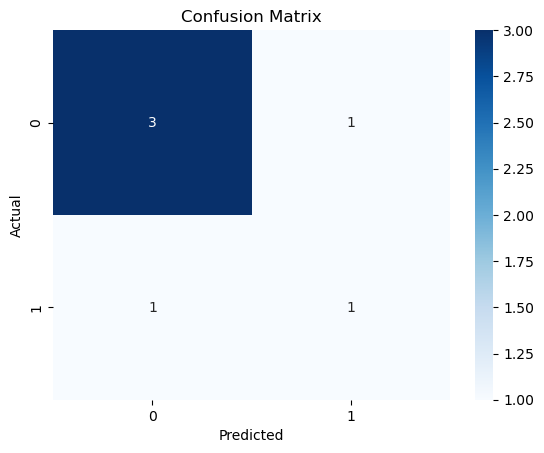

In [13]:
print("--- Classification Report ---")
print(classification_report(y_test, y_pred))

# Visualizing the Confusion Matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

C:\Users\pisin\AppData\Local\Temp\ipykernel_8260\1087295313.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


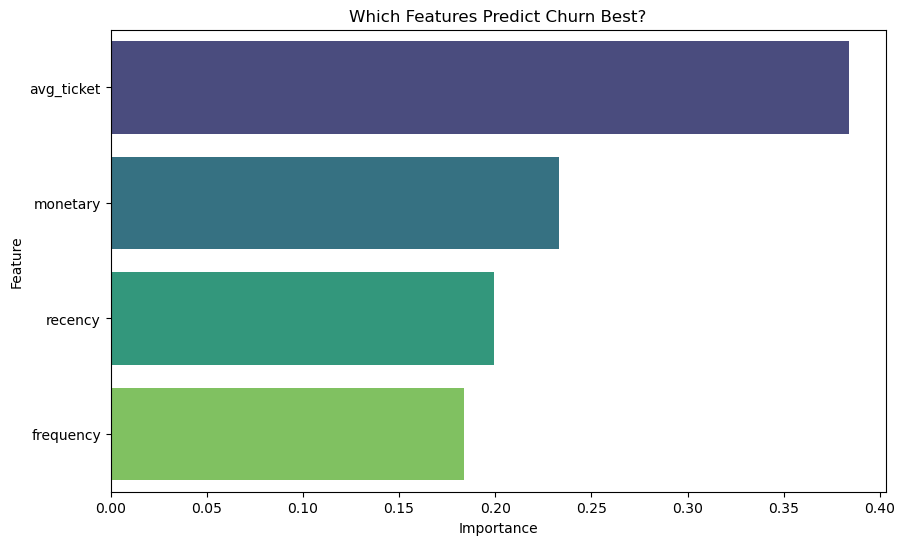

In [14]:
# 1. Get feature importance from the trained model
importances = model.feature_importances_
feature_names = X.columns

# 2. Create a DataFrame for visualization
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# 3. Plot the results
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Which Features Predict Churn Best?')
plt.show()

In [15]:
# Imagine a new customer: 
# Recency: 45 days, Frequency: 1 order, Monetary: $50, Avg Ticket: $50
new_customer = np.array([[45, 1, 50, 50]])

# Scale the input just like we did for the training data
new_customer_scaled = scaler.transform(new_customer)

# Predict Probability
prob = model.predict_proba(new_customer_scaled)[0][1]

print(f"Churn Probability for this customer: {prob:.2%}")

if prob > 0.7:
    print("Action: Send high-value 'We Miss You' discount code.")
else:
    print("Action: Standard newsletter tracking.")

Churn Probability for this customer: 13.00%
Action: Standard newsletter tracking.


C:\Users\pisin\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [16]:
import joblib

# 1. Save the model to a file
joblib.dump(model, 'churn_model.pkl')

# 2. Save the scaler to a file
joblib.dump(scaler, 'scaler.pkl')

print("Model and Scaler saved as .pkl files!")

Model and Scaler saved as .pkl files!


In [17]:
# How to load and use the model in a different file:
loaded_model = joblib.load('churn_model.pkl')
loaded_scaler = joblib.load('scaler.pkl')

def predict_customer_vibe(r, f, m):
    # Calculate avg_ticket manually for the input
    avg_t = m / f
    input_data = np.array([[r, f, m, avg_t]])
    
    # Scale and Predict
    scaled_input = loaded_scaler.transform(input_data)
    prediction = loaded_model.predict(scaled_input)
    
    return "Churn Risk" if prediction[0] == 1 else "Loyal"

# Example: A customer who hasn't bought in 40 days
print(f"Customer Status: {predict_customer_vibe(40, 1, 100)}")

Customer Status: Loyal


C:\Users\pisin\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [19]:
import streamlit as st
import joblib
import numpy as np

In [20]:

# 1. Load the saved model and scaler
model = joblib.load('churn_model.pkl')
scaler = joblib.load('scaler.pkl')

# 2. Set up the UI
st.title("📊 E-Commerce Churn Predictor")
st.markdown("Enter customer details below to see the probability of them leaving.")

# 3. Create Input Sliders
col1, col2 = st.columns(2)

with col1:
    recency = st.slider("Recency (Days since last purchase)", 0, 60, 20)
    frequency = st.number_input("Frequency (Total Orders)", 1, 50, 1)

with col2:
    monetary = st.number_input("Monetary (Total Spend $)", 10.0, 5000.0, 100.0)
    
# 4. Calculation and Prediction
if st.button("Predict Churn Risk"):
    avg_ticket = monetary / frequency
    features = np.array([[recency, frequency, monetary, avg_ticket]])
    
    # Scale and Predict
    features_scaled = scaler.transform(features)
    prob = model.predict_proba(features_scaled)[0][1]
    
    # Display Result
    st.subheader(f"Churn Probability: {prob:.2%}")
    if prob > 0.7:
        st.error("⚠️ High Risk: This customer is likely to churn.")
    elif prob > 0.4:
        st.warning("🟡 Medium Risk: Consider sending a follow-up email.")
    else:
        st.success("✅ Low Risk: This is a loyal customer.")

2026-03-18 20:57:46.676 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-18 20:57:47.046 
  command:

    streamlit run C:\Users\pisin\anaconda3\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-03-18 20:57:47.049 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-18 20:57:47.051 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-18 20:57:47.054 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-18 20:57:47.056 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-18 20:57:47.060 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-18 20:57:47.072 Thread 'MainThread': mi